# Carry Signal — Data Explorer

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_parquet('../data/signals.parquet')
btc = df[df.symbol == 'BTC'].copy()
eth = df[df.symbol == 'ETH'].copy()

## Schema

In [2]:
print(f"Rows: {len(df)}, Columns: {list(df.columns)}")
df.dtypes

Rows: 13692, Columns: ['timestamp', 'symbol', 'funding_rate', 'realized_vol_30d', 'signal']


timestamp           datetime64[ns, UTC]
symbol                           object
funding_rate                    float64
realized_vol_30d                float64
signal                            int64
dtype: object

## First & last rows

In [3]:
btc.head(10)

,timestamp,symbol,funding_rate,realized_vol_30d,signal
0,2020-01-01 00:00:00+00:00,BTC,-0.000124,NaN,0
1,2020-01-01 08:00:00+00:00,BTC,-0.000124,NaN,0
2,2020-01-01 16:00:00+00:00,BTC,-0.000097,NaN,0
3,2020-01-02 00:00:00.002000+00:00,BTC,0.000037,NaN,0
4,2020-01-02 08:00:00+00:00,BTC,0.000100,NaN,0
5,2020-01-02 16:00:00+00:00,BTC,0.000001,NaN,0
6,2020-01-03 00:00:00+00:00,BTC,-0.000017,NaN,0
7,2020-01-03 08:00:00+00:00,BTC,-0.000016,NaN,0
8,2020-01-03 16:00:00.001000+00:00,BTC,0.000100,NaN,0
9,2020-01-04 00:00:00+00:00,BTC,0.000100,NaN,0


In [4]:
btc.tail(10)

,timestamp,symbol,funding_rate,realized_vol_30d,signal
6836,2026-03-28 16:00:00+00:00,BTC,-1.730000e-06,0.647729,0
6837,2026-03-29 00:00:00.003000+00:00,BTC,-3.680000e-05,0.647729,0
6838,2026-03-29 08:00:00.001000+00:00,BTC,-1.200000e-07,0.647729,0
6839,2026-03-29 16:00:00+00:00,BTC,2.677000e-05,0.647729,0
6840,2026-03-30 00:00:00+00:00,BTC,3.000000e-06,0.647729,0
6841,2026-03-30 08:00:00.005000+00:00,BTC,4.920000e-06,0.647729,0
6842,2026-03-30 16:00:00+00:00,BTC,7.580000e-06,0.647729,0
6843,2026-03-31 00:00:00+00:00,BTC,1.160000e-06,0.647729,0
6844,2026-03-31 08:00:00+00:00,BTC,-1.921000e-05,0.647729,0
6845,2026-03-31 16:00:00+00:00,BTC,-2.763000e-05,0.647729,0


## Coverage & nulls

In [5]:
for name, sub in [('BTC', btc), ('ETH', eth)]:
    print(f"{name}: {len(sub)} periods, {sub['timestamp'].min()} → {sub['timestamp'].max()}")
    print(f"  Null vol: {sub['realized_vol_30d'].isna().sum()}")
print(f"\nTotal rows: {len(df)}")

BTC: 6846 periods, 2020-01-01 00:00:00+00:00 → 2026-03-31 16:00:00+00:00
  Null vol: 45
ETH: 6846 periods, 2020-01-01 00:00:00+00:00 → 2026-03-31 16:00:00+00:00
  Null vol: 45

Total rows: 13692


## Funding rate distribution

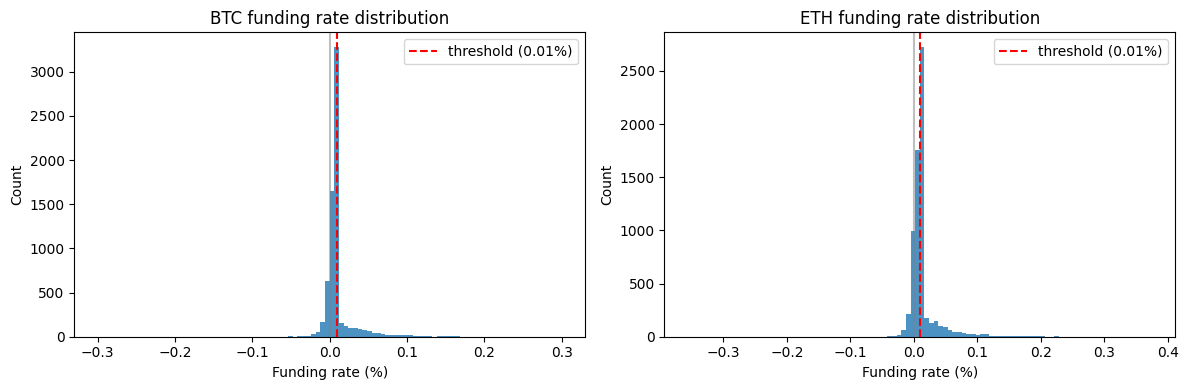

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, sub) in zip(axes, [('BTC', btc), ('ETH', eth)]):
    ax.hist(sub['funding_rate'] * 100, bins=100, edgecolor='none', alpha=0.8)
    ax.axvline(0.01, color='red', ls='--', label='threshold (0.01%)')
    ax.axvline(0, color='grey', ls='-', alpha=0.5)
    ax.set_title(f'{name} funding rate distribution')
    ax.set_xlabel('Funding rate (%)')
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.show()

## Signal summary — % time in carry

In [7]:
for name, sub in [('BTC', btc), ('ETH', eth)]:
    on = sub['signal'].sum()
    n = len(sub)
    print(f"{name}: signal ON {on}/{n} periods ({on/n*100:.1f}%)")
    print(f"  Funding when ON:  mean={sub.loc[sub.signal==1, 'funding_rate'].mean()*100:.4f}%")
    neg = (sub.loc[sub.signal==1, 'funding_rate'] < 0).sum()
    print(f"  Negative funding while ON: {neg}")
    print()

BTC: signal ON 1046/6846 periods (15.3%)
  Funding when ON:  mean=0.0458%
  Negative funding while ON: 0

ETH: signal ON 1226/6846 periods (17.9%)
  Funding when ON:  mean=0.0517%
  Negative funding while ON: 0



## Threshold sensitivity

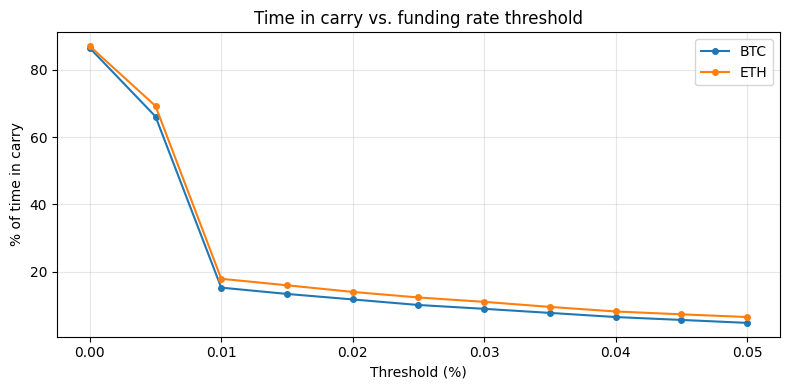

In [8]:
thresholds = np.arange(0, 0.00055, 0.00005)
rows = []
for t in thresholds:
    for name, sub in [('BTC', btc), ('ETH', eth)]:
        mask = sub['funding_rate'] > t
        rows.append({'threshold_pct': t * 100, 'symbol': name, 'pct_in_carry': mask.mean() * 100,
                     'mean_funding_when_in': sub.loc[mask, 'funding_rate'].mean() * 100 if mask.any() else 0})
sens = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4))
for name in ['BTC', 'ETH']:
    sub = sens[sens.symbol == name]
    ax.plot(sub['threshold_pct'], sub['pct_in_carry'], marker='o', markersize=4, label=name)
ax.set_xlabel('Threshold (%)')
ax.set_ylabel('% of time in carry')
ax.set_title('Time in carry vs. funding rate threshold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Realized vol distribution

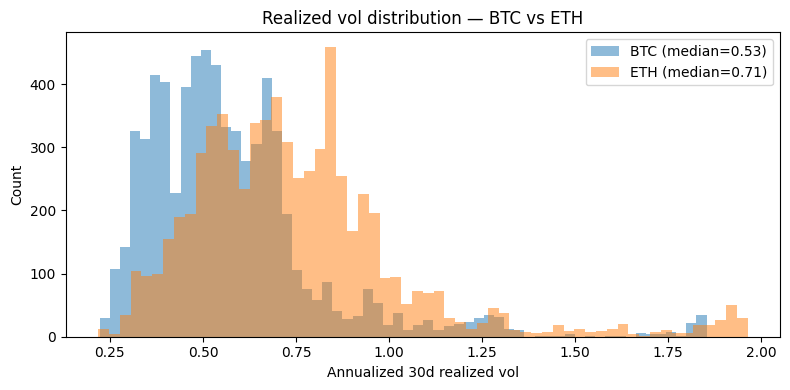

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, sub in [('BTC', btc), ('ETH', eth)]:
    v = sub['realized_vol_30d'].dropna()
    ax.hist(v, bins=60, alpha=0.5, label=f'{name} (median={v.median():.2f})')
ax.set_xlabel('Annualized 30d realized vol')
ax.set_ylabel('Count')
ax.set_title('Realized vol distribution — BTC vs ETH')
ax.legend()
plt.tight_layout()
plt.show()

## Signal over time

Rolling 30-day % of periods with signal ON.

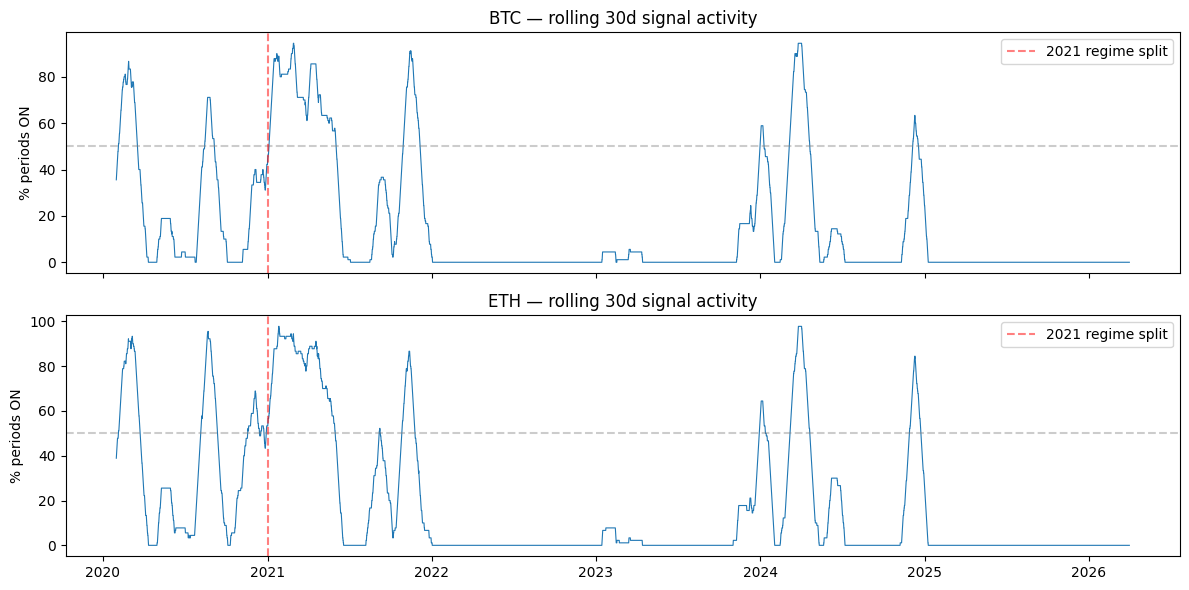

In [10]:
window = 30 * 3  # 30 days at 3 periods/day

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, (name, sub) in zip(axes, [('BTC', btc), ('ETH', eth)]):
    rolling_pct = sub.set_index('timestamp')['signal'].rolling(window).mean() * 100
    ax.plot(rolling_pct.index, rolling_pct.values, linewidth=0.8)
    ax.axhline(50, color='grey', ls='--', alpha=0.4)
    ax.axvline(pd.Timestamp('2021-01-01', tz='UTC'), color='red', ls='--', alpha=0.5, label='2021 regime split')
    ax.set_ylabel('% periods ON')
    ax.set_title(f'{name} — rolling 30d signal activity')
    ax.legend()
plt.tight_layout()
plt.show()

## Pre-2021 vs post-2021 comparison

In [11]:
split = pd.Timestamp('2021-01-01', tz='UTC')
rows = []
for name, sub in [('BTC', btc), ('ETH', eth)]:
    for label, mask in [('Pre-2021', sub.timestamp < split), ('Post-2021', sub.timestamp >= split)]:
        s = sub[mask]
        rows.append({
            'symbol': name, 'regime': label, 'periods': len(s),
            'pct_on': s['signal'].mean() * 100,
            'mean_funding_pct': s['funding_rate'].mean() * 100,
            'median_funding_pct': s['funding_rate'].median() * 100,
            'mean_vol': s['realized_vol_30d'].mean(),
        })
pd.DataFrame(rows).set_index(['symbol', 'regime'])

periods     pct_on  mean_funding_pct  median_funding_pct  \
symbol regime                                                                
BTC    Pre-2021      1098  26.775956          0.015701            0.010000   
       Post-2021     5748  13.082811          0.010443            0.008455   
ETH    Pre-2021      1098  37.431694          0.025036            0.010000   
       Post-2021     5748  14.178845          0.011225            0.008492   

                  mean_vol  
symbol regime               
BTC    Pre-2021   0.653325  
       Post-2021  0.562693  
ETH    Pre-2021   0.852629  
       Post-2021  0.734572

## BTC vs ETH signal correlation

How often do BTC and ETH signals agree?

In [12]:
merged = btc[['timestamp', 'signal']].rename(columns={'signal': 'btc_signal'}).merge(
    eth[['timestamp', 'signal']].rename(columns={'signal': 'eth_signal'}),
    on='timestamp', how='inner'
)
both_on = ((merged.btc_signal == 1) & (merged.eth_signal == 1)).sum()
both_off = ((merged.btc_signal == 0) & (merged.eth_signal == 0)).sum()
btc_only = ((merged.btc_signal == 1) & (merged.eth_signal == 0)).sum()
eth_only = ((merged.btc_signal == 0) & (merged.eth_signal == 1)).sum()
n = len(merged)

print(f"Both ON:   {both_on:>5d} ({both_on/n*100:.1f}%)")
print(f"Both OFF:  {both_off:>5d} ({both_off/n*100:.1f}%)")
print(f"BTC only:  {btc_only:>5d} ({btc_only/n*100:.1f}%)")
print(f"ETH only:  {eth_only:>5d} ({eth_only/n*100:.1f}%)")
print(f"Agreement: {(both_on+both_off)/n*100:.1f}%")

Both ON:     905 (13.2%)
Both OFF:   5479 (80.0%)
BTC only:    141 (2.1%)
ETH only:    321 (4.7%)
Agreement: 93.3%


## Funding rate autocorrelation

Does high funding persist? (relevant for signal profitability)

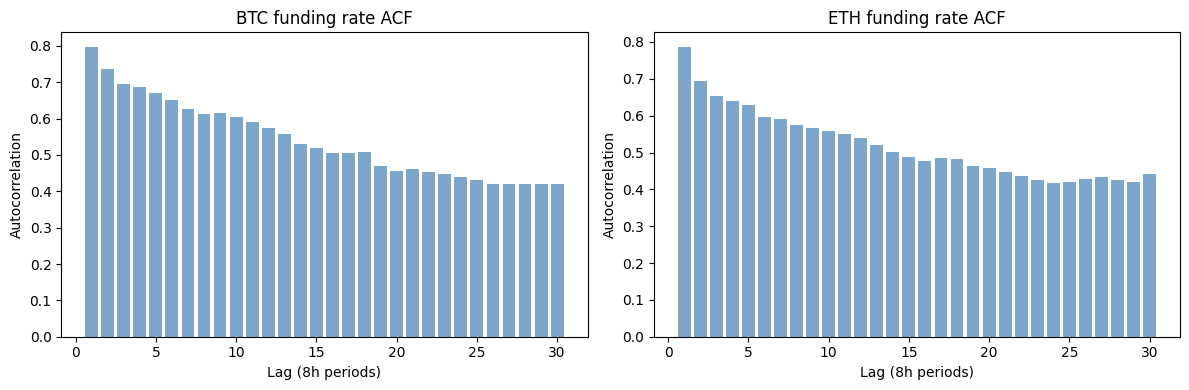

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
max_lags = 30  # up to 30 periods = 10 days
for ax, (name, sub) in zip(axes, [('BTC', btc), ('ETH', eth)]):
    fr = sub['funding_rate'].values
    acf = [np.corrcoef(fr[:-lag], fr[lag:])[0, 1] for lag in range(1, max_lags + 1)]
    ax.bar(range(1, max_lags + 1), acf, color='steelblue', alpha=0.7)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xlabel('Lag (8h periods)')
    ax.set_ylabel('Autocorrelation')
    ax.set_title(f'{name} funding rate ACF')
plt.tight_layout()
plt.show()

## Yearly signal summary

In [14]:
df['year'] = df['timestamp'].dt.year
yearly = df.groupby(['year', 'symbol']).agg(
    periods=('signal', 'count'),
    pct_on=('signal', 'mean'),
    mean_funding=('funding_rate', 'mean'),
    mean_vol=('realized_vol_30d', 'mean'),
).round(4)
yearly['pct_on'] = (yearly['pct_on'] * 100).round(1)
yearly['mean_funding'] = (yearly['mean_funding'] * 100).round(4)
yearly

periods  pct_on  mean_funding  mean_vol
year symbol                                         
2020 BTC        1098    26.8          0.02    0.6533
     ETH        1098    37.4          0.03    0.8526
2021 BTC        1095    42.9          0.03    0.8358
     ETH        1095    45.4          0.03    1.0511
2022 BTC        1095     0.0          0.00    0.6285
     ETH        1095     0.0          0.00    0.8377
2023 BTC        1095     6.3          0.01    0.4097
     ETH        1095     6.9          0.01    0.4476
2024 BTC        1098    19.4          0.01    0.5126
     ETH        1098    22.0          0.01    0.6210
2025 BTC        1095     0.0          0.00    0.4364
     ETH        1095     0.0          0.00    0.7228
2026 BTC         270     0.0          0.00    0.5248
     ETH         270     0.0          0.00    0.7061